# Dimension Reduction Methods

## 1. Overview

Today we learned about dimensionality reduction and principal component analysis in particular. Here in this notebook, we will use PCA to revisit the breast cancer data from class 13. This will save us some time with the exploratory data analysis, so we will have more time to focus and think about how dimension reduction can help us in our analytic workflow. 

If necessary, refresh your memory on the dataset here: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data.



## 2. Import and data prep
### 2.1. Importing Dependencies

As usual, we start by importing libraries we will use later on. Throughout the notebook, if any functions are unclear, try googling the library and function to familiarize yourself with the functions and their in- and outputs. 

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn import decomposition
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.metrics import accuracy_score,confusion_matrix

### 2.2. Load data

**TASK:** Load the file ```breast-cancer-wisconsin.csv``` located in the same directory as this notebook using ```read_csv()``` from pandas.

In [2]:
data = pd.read_csv('breast-cancer-wisconsin.csv')

### 2.3. Data summary

As usual, we start by having a peak at the data. 

**TASK:** Use ```head()```, ```describe()``` and ```info()``` on the dataframe to get a first idea.

In [3]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 2.4. Data preparation

#### 2.4.1. Data clean-up

**TASK:** We don't need the first and last column ('id', 'Unnamed: 32') - drop them. 

In [4]:
# Cleaning and modifying the data
data = data.drop(columns = ['id', 'Unnamed: 32'])

ndat, nvar = data.shape # this saves the number of rows as ndat and the number of columns as nvar which we might need later
ndat, nvar

(569, 31)

#### 2.4.2. Label encoding

Finally, we map the diagnostic values to binary values. 

In [5]:
data['diagnosis'] = data['diagnosis'].map({'M':1,'B':0})

# alternative using LabelEncoder()
# le = LabelEncoder()
# y = le.fit_transform(y)

**TASK:** Assign the data to ```X```, excluding ```diagnosis```, and assign the latter to ```y```.

In [6]:
X = data.loc[:, 'radius_mean':'fractal_dimension_worst']

y = data.loc[:, 'diagnosis']

#### 2.4.3. Data scaling

We learned about the importance of scaling data whenever working with distance-based methods.

**TASK:** Use the function ```StandardScaler()``` to scale the data. Use ```describe()``` to see how the data has changed. 

In [7]:
#scaling of variables
sc = StandardScaler()
scaled_X = sc.fit_transform(X.values)
pd.DataFrame(scaled_X, columns=X.columns).describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,5.690000e+02,5.690000e+02,569.000000,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02
mean,-1.373633e-16,6.868164e-17,-1.248757e-16,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-8.241796e-16,1.248757e-17,-3.746271e-16,0.000000,-2.372638e-16,-3.371644e-16,7.492542e-17,2.247763e-16,2.622390e-16,-5.744282e-16
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,1.000880e+00,1.000880e+00,1.000880,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.726901e+00,-2.223994e+00,-1.693361e+00,-1.222423,-2.682695e+00,-1.443878e+00,-1.305831e+00,-1.745063e+00,-2.160960e+00,-1.601839e+00
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.749213e-01,-7.486293e-01,-6.895783e-01,-0.642136,-6.912304e-01,-6.810833e-01,-7.565142e-01,-7.563999e-01,-6.418637e-01,-6.919118e-01
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.690395e-01,-4.351564e-02,-2.859802e-01,-0.341181,-4.684277e-02,-2.695009e-01,-2.182321e-01,-2.234689e-01,-1.274095e-01,-2.164441e-01
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,5.220158e-01,6.583411e-01,5.402790e-01,0.357589,5.975448e-01,5.396688e-01,5.311411e-01,7.125100e-01,4.501382e-01,4.507624e-01
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,4.094189e+00,3.885905e+00,4.287337e+00,5.930172,3.955374e+00,5.112877e+00,4.700669e+00,2.685877e+00,6.046041e+00,6.846856e+00


**TASK:** Compare the scaled data to the original unscaled data - what did the scaling do?

## 3. Exploratory data analysis

**TASK:** Check out last session's notebook on clustering to refresh your memory on the dataset. Perhaps you can think of aspects to explore that you didn't check last time. 

Last time, we only looked at the correlation matrix of the data. Now we could check out the covariance matrix of the data or its scaled version as we heard in the lecture that they have something to do with the PCA projection. How do the correlation matrix and the covariance matrix relate to each other?

Text(0.5, 1.0, 'Correlation Matrix Heatmap for Breast Cancer dataset')

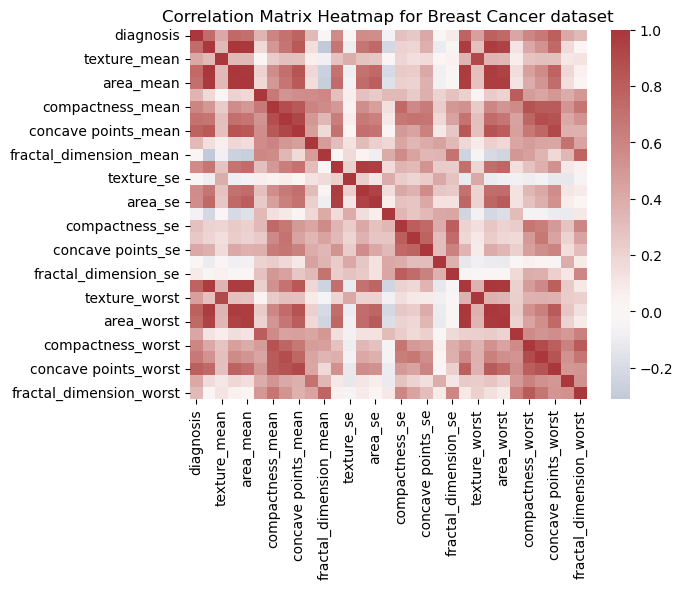

In [8]:
corr_matrix = data.corr()

fig = sns.heatmap(corr_matrix, center = 0, cmap = sns.color_palette("vlag", as_cmap=True))
fig.set_title('Correlation Matrix Heatmap for Breast Cancer dataset')

**TIP:** To calculate covariance, use the `cov` function from pandas.

Text(0.5, 1.0, 'Covariation Matrix Heatmap for Breast Cancer dataset')

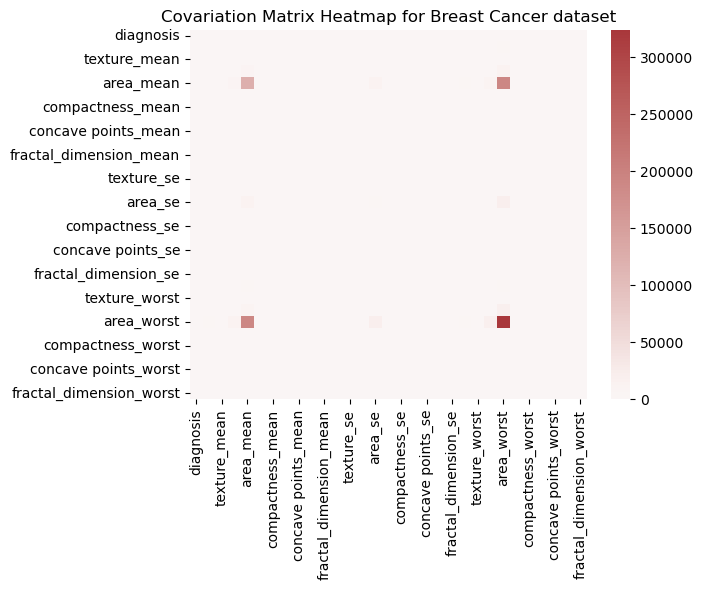

In [9]:
cov_matrix = data.cov()

fig = sns.heatmap(cov_matrix, center = 0, cmap = sns.color_palette("vlag", as_cmap=True))
fig.set_title('Covariation Matrix Heatmap for Breast Cancer dataset')

### 3.1. For the mathematically curious

Using the ```linalg``` library from numpy, compute the eigenvalues of the above covariance matrix. Create two bar plots of the unnormalized and normalized eigenvalues (i.e. divided by the sum of eigenvalues). We can check later if they coincide with the explained variances by the PC's.

**TIP:** convert the covariance matrix to an array first, before feeding it to the linalg library, using the function `to_numpy`.

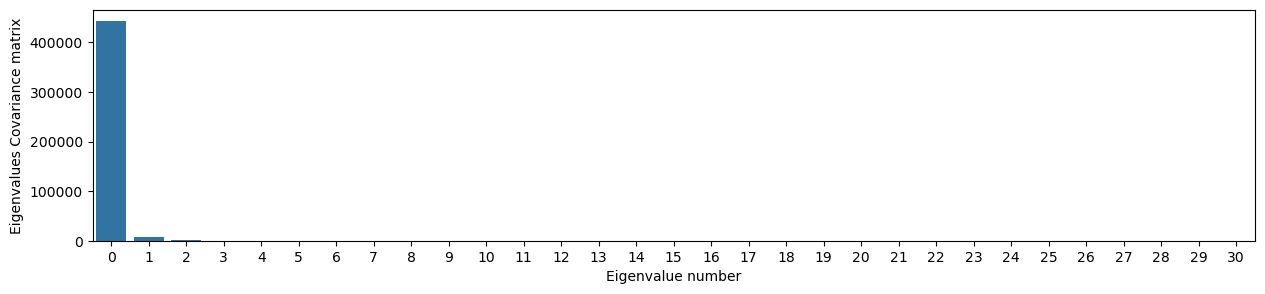

In [10]:
from numpy import linalg

eigenvalues, eigenvectors = linalg.eig(cov_matrix)

df_ev = pd.DataFrame({'Eigenvalues Covariance matrix': eigenvalues,
                      'Normalized eigenvalues': eigenvalues / np.sum(eigenvalues),
                      'Eigenvalue number' : range(len(eigenvalues))})

plt.figure(figsize = (15,3))
sns.barplot(x = 'Eigenvalue number', y = 'Eigenvalues Covariance matrix', data = df_ev);

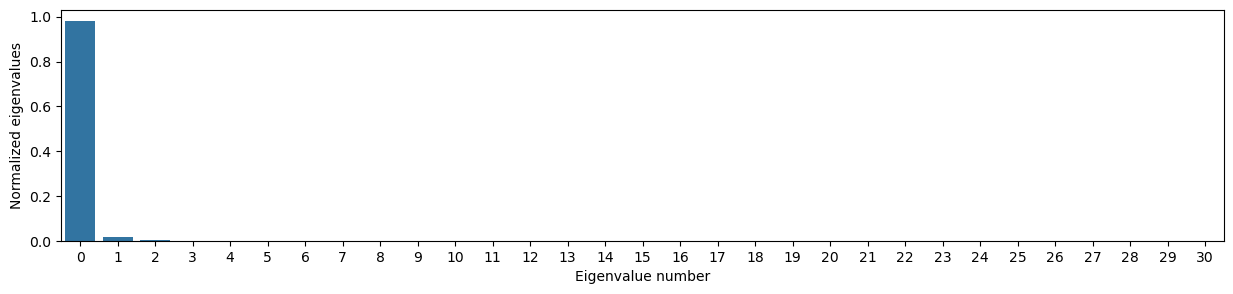

In [11]:
plt.figure(figsize = (15,3))
sns.barplot(x = 'Eigenvalue number',y = 'Normalized eigenvalues',data = df_ev);

## 4. Principal Component Analysis (PCA)
Now we will use PCA to find a linear projection of the variable space. First, we will look at the full PCA space to then decide how to reduce it. 

### 4.1. Full PCA

**TASK:** Create a PCA object called ```pca``` using ```decomposition.PCA()```, then transform the data into the PCA space by using ```fit_transform``` on ```scaled_X```. Check out the transformed data.

In [12]:
pca = decomposition.PCA()
tdata = pca.fit_transform(scaled_X)
tdata

array([[ 9.19283683e+00,  1.94858307e+00, -1.12316616e+00, ...,
         3.39144536e-02, -4.56477199e-02,  4.71692081e-02],
       [ 2.38780180e+00, -3.76817174e+00, -5.29292687e-01, ...,
        -3.26241827e-02,  5.68742432e-03,  1.86787626e-03],
       [ 5.73389628e+00, -1.07517380e+00, -5.51747593e-01, ...,
        -4.70258247e-02, -3.14589659e-03, -7.50534755e-04],
       ...,
       [ 1.25617928e+00, -1.90229671e+00,  5.62730526e-01, ...,
         2.57775589e-03, -6.70621179e-03, -3.77041667e-03],
       [ 1.03747941e+01,  1.67201011e+00, -1.87702933e+00, ...,
         6.80863833e-02,  8.41632764e-02,  2.37828222e-02],
       [-5.47524330e+00, -6.70636791e-01,  1.49044308e+00, ...,
         9.51587894e-03,  6.09131090e-02,  1.94755854e-02]])

**Reflect:** Have the dimensions been reduced? What is the new transformed data?

We can see above that the dimensions after PCA have not reduced. We've got entire set of new features projected onto the principal componenets. We have to find which or if all components are actualy important. 

### 4.2. Analysis of the PCA space

**TASK:** Check out the ```explained_variance_``` and ```explained_variance_ratio_``` attributes of the pca object. Create bar plots of them and compare to the bar plots of the eigenvalue

In [13]:
#Information content by all new indep variables
pca.explained_variance_ratio_

array([4.42720256e-01, 1.89711820e-01, 9.39316326e-02, 6.60213492e-02,
       5.49576849e-02, 4.02452204e-02, 2.25073371e-02, 1.58872380e-02,
       1.38964937e-02, 1.16897819e-02, 9.79718988e-03, 8.70537901e-03,
       8.04524987e-03, 5.23365745e-03, 3.13783217e-03, 2.66209337e-03,
       1.97996793e-03, 1.75395945e-03, 1.64925306e-03, 1.03864675e-03,
       9.99096464e-04, 9.14646751e-04, 8.11361259e-04, 6.01833567e-04,
       5.16042379e-04, 2.72587995e-04, 2.30015463e-04, 5.29779290e-05,
       2.49601032e-05, 4.43482743e-06])

**TASK:** Make a scree plot / elbow plot based on the ```explained_variance_ratio_```. Is there a clear scree point / elbow?

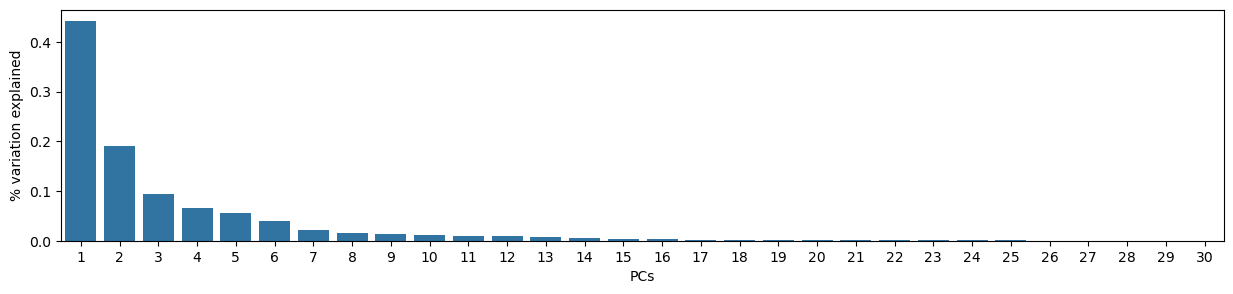

In [14]:
df_expvar = pd.DataFrame({'% variation explained': pca.explained_variance_ratio_,
                          'PCs': range(1,nvar)})

plt.figure(figsize = (15,3))
sns.barplot(x = 'PCs',y = '% variation explained',data = df_expvar);

**TASK:** Now plot the cumulative explained variance ratios using ```np.comsum()```. Do you find this or the scree plot more informative?

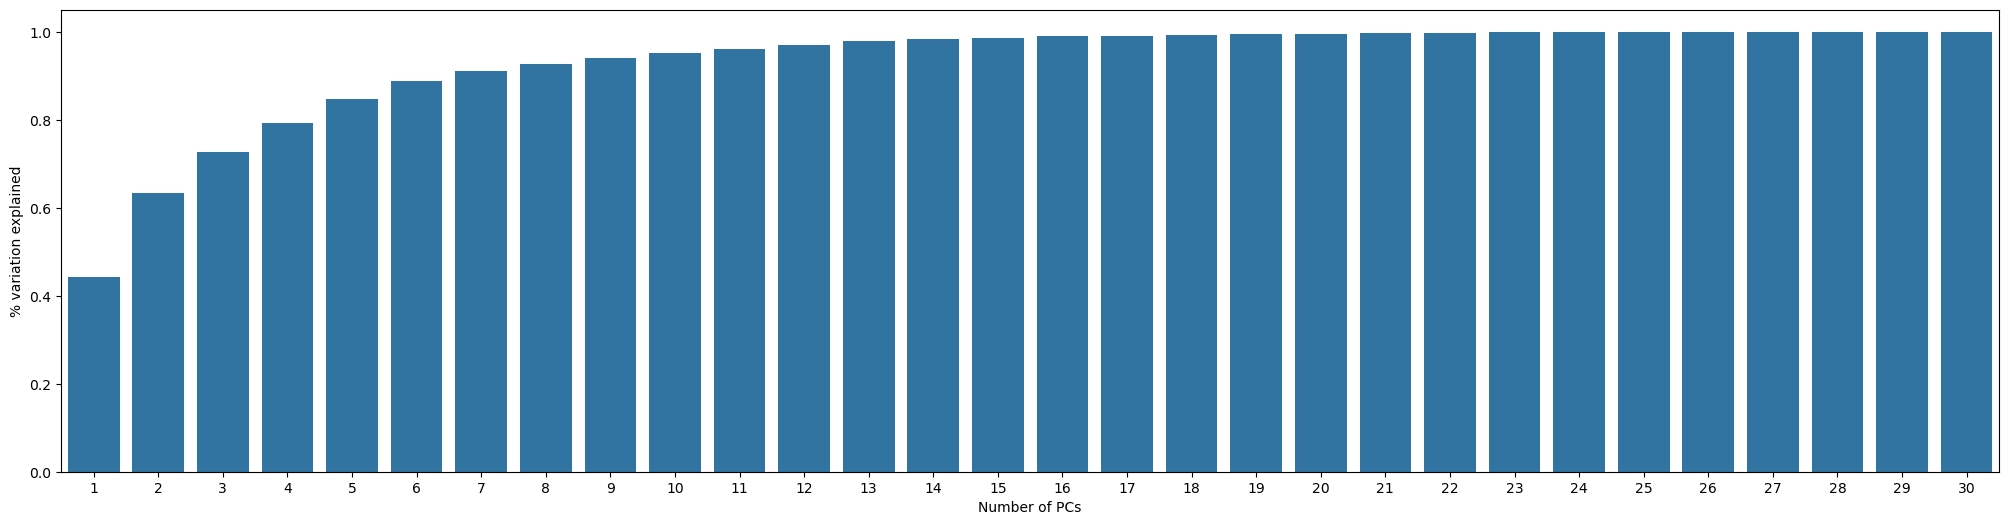

In [15]:
df_cexpvar = pd.DataFrame({'% variation explained': np.cumsum(pca.explained_variance_ratio_),
                    'Number of PCs': range(1,nvar)})

plt.figure(figsize = (25,6))
sns.barplot(x = 'Number of PCs',y = '% variation explained',data = df_cexpvar);

**Reflect:** Look at the scree and the cumulative plots. How many components are required to explain at least 80% of the variance in the data?

We can see that over 80% of information is explained by the first five components. 

**Optional TASK:** If you checked out the eigenvalues of the covariance matrix in the optional task in **§3.1**, now check out the ```explained_variance_``` attribute of our pca object. Make a plot and compare both this and the scree plot to those in **§3.1**. How do they relate to each other?

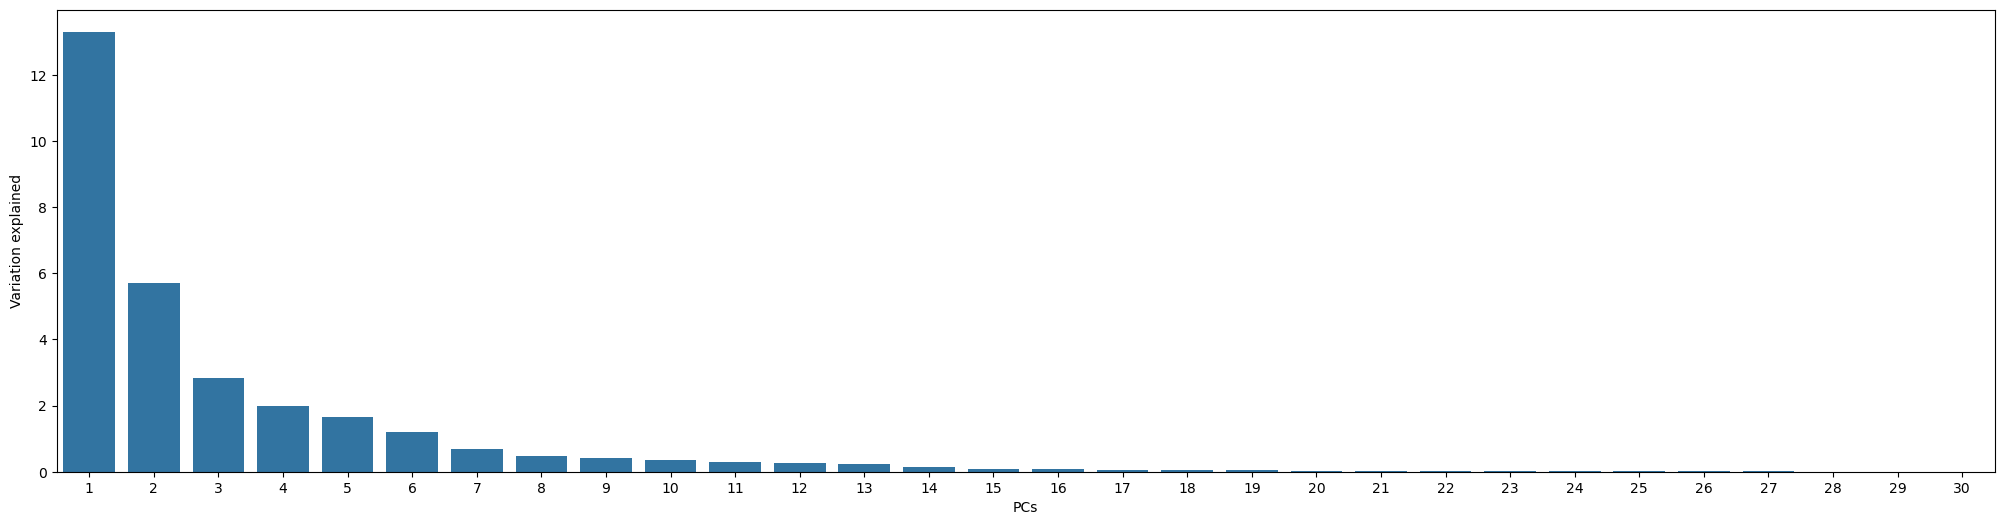

In [16]:
df1 = pd.DataFrame({'Variation explained':pca.explained_variance_,
                    'PCs':range(1,nvar)})

plt.figure(figsize = (25,6))
sns.barplot(x = 'PCs',y = 'Variation explained',data = df1);

### 4.4. Reduced PCA


Above, we learned that 5 components are required to explain at least 80% of the variance in our data. Let's now do dimension reduction by only looking at the first 5 components. 

**TASK:** Again using ```decomposition.PCA()``` now compute a PCA projection of the data setting ```n_components=5```. Then transform ```scaled_X``` into the reduced PCA space and store in ```pca_5var```.

In [17]:
#we will do PCA with only 5 components now as they seem to provide 80% of the information.
pca_red = decomposition.PCA(n_components=5)
pca_5var = pca_red.fit_transform(scaled_X)

**TASK:** Check out ```explained_variance_``` and its sum to make sure we really explained at least 80% of our data variance.

In [18]:
pca_red.explained_variance_

array([13.30499079,  5.7013746 ,  2.82291016,  1.98412752,  1.65163324])

In [19]:
np.sum(pca_red.explained_variance_ratio_)*100

84.73427431680723

We can see that over 80% information is obtained in first 5 components.

**TASK:** Create a dataframe ```X_5PCs``` from the transformed data using ```pd.DataFrame()``` on the transformed data, i.e. using ```columns=['PC1','PC2','PC3','PC4','PC5']``` of ```pca_5var```. Check it out using ```head()```.

In [20]:
X_5PCs = pd.DataFrame(pca_5var,columns=['PC1','PC2','PC3','PC4','PC5'])
X_5PCs.head()

,PC1,PC2,PC3,PC4,PC5
0,9.192837,1.948583,-1.123166,-3.633731,1.195110
1,2.387802,-3.768172,-0.529293,-1.118264,-0.621775
2,5.733896,-1.075174,-0.551748,-0.912083,0.177086
3,7.122953,10.275589,-3.232790,-0.152547,2.960878
4,3.935302,-1.948072,1.389767,-2.940639,-0.546747


**TASK:** In the lecture, we learned that PCA makes a rotated projection of the data, where correlations have been removed. Check if that's true.

In [21]:
X_5PCs.corr()

,PC1,PC2,PC3,PC4,PC5
PC1,1.000000e+00,1.355507e-16,-6.633908e-17,1.826043e-16,4.836774e-17
PC2,1.355507e-16,1.000000e+00,-5.398379e-17,-7.031900e-17,-1.012455e-16
PC3,-6.633908e-17,-5.398379e-17,1.000000e+00,6.276856e-18,-6.092165e-17
PC4,1.826043e-16,-7.031900e-17,6.276856e-18,1.000000e+00,2.240466e-16
PC5,4.836774e-17,-1.012455e-16,-6.092165e-17,2.240466e-16,1.000000e+00


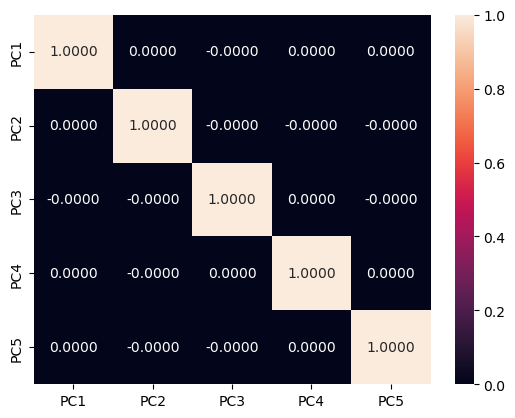

In [22]:
sns.heatmap(X_5PCs.corr(), annot= True, fmt='.4f');


We can see that there is no correlation among the principal components which is very important. 

## 5. Classification of the breast cancer data

### 5.1. On the reduced PCA space

We will now train LogisticRegression on the data projected onto the 5 principal components.

**Reflect:** Why would we choose logistic regression on this data? 

Logistic regression is a classification method for binary outcome data.

**TASK:** Use ```train_test_split()``` on ```X_5PCs``` and ```y``` to create a test-train data split with ```test_size=0.2``` and setting ```random_state``` to any number of your choice.

In [23]:
X_5PCs_train, X_5PCs_test, y_train, y_test = train_test_split(X_5PCs, y, test_size = 0.2, random_state = 42)

**TASK:** Create a model called ```logreg``` using ```LogisticRegression()``` and setting ```solver='lbfgs'```. Fit the model on the training data using ```fit()``` and then make predictions on the test set using ```predict()``` on the logreg model. 

In [30]:
# create logreg model
logreg = LogisticRegression(solver='lbfgs')
# fit on training data
logreg.fit(X_5PCs_train, y_train)
# predict on test data
y_pred_test = logreg.predict(X_5PCs_test)

**TASK:** Print the confusion matrix and the accuracy of the logreg model using ```confusion_matrix()``` and ```accuracy_score()``` on the test data.

In [25]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_pred_test))
print()
print('Using logistic regression on the reduced PCA space, we get an accuracy of ' + str(round(accuracy_score(y_test,y_pred_test)*100, 2)) + '%.')

Confusion matrix:
[[70  1]
 [ 1 42]]

Using logistic regression on the reduced PCA space, we get an accuracy of 98.25%.


### 5.2. On the original data space

Now let's see how the regression on the reduced PCA space compares to regression on the original data space. 

**TASK:** Use ```train_test_split()``` on ```X``` and ```y``` to create a test-train data split with ```test_size=0.2``` and setting ```random_state``` to any number of your choice.

In [26]:
#let's compare Logistic Regession without PCA when we have all of the original features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

**TASK:** Create a model called ```logreg2``` using ```LogisticRegression()``` and setting ```solver='lbfgs'```. Fit the model on the training data using ```fit()``` and then make predictions on the test set using ```predict()``` on the ```logreg2``` model. 

In [32]:
# create logreg model
logreg2 = LogisticRegression(solver='lbfgs')
# fit on training data, all variables 
logreg2.fit(X_train, y_train)

# predict on test data
y_pred_test2 = logreg2.predict(X_test)
# ignore the warning

/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**TASK:** Print the confusion matrix and the accuracy of the logreg2 model using ```confusion_matrix()``` and ```accuracy_score()``` on the test data.

In [33]:
print('Confusion matrix:')
print(confusion_matrix(y_test,y_pred_test2))
print()
print('Using logistic regression on the original space, we get an accuracy of ' + str(round(accuracy_score(y_test,y_pred_test2)*100, 2)) + '%.')

Confusion matrix:
[[70  1]
 [ 4 39]]

Using logistic regression on the original space, we get an accuracy of 95.61%.


**TASK:** Compare the accuracy we got for classification when using the original data and when it's been projected onto the reduced PCA space. 

Accuracy is already high without PCA, but we can see that we gain accuracy when PCA is used compared to when it is not used. Since correlation has been removed from the data, the classifier has an easier task. 

**Optional TASK:** Can we get even better classification results by using more principal components?

### 5.3. Visualizing the classification results

Let's visualize the classification results on the whole data set.

**TASK:** First make predictions from the logreg models fitted on the reduced PCA and the original space, i.e. ```logreg``` and ```logreg2```, this time on the whole dataset, i.e. on ```X_5PCs``` and ```X```, respectively.

In [31]:
y_pred_all = logreg.predict(X_5PCs)
y_pred_all2 = logreg2.predict(X)

**TASK:** Make 3 scatter plots of the data projected onto the first two components, i.e. plotting ```X_5PCs.PC1``` vs ```X_5PCs.PC2```, and colour the points by 
1. Predictions from classification on the reduced PCA space.
2. Predictions from classification on the original data space.
3. True diagnoses.

Text(0, 0.5, 'PC2')

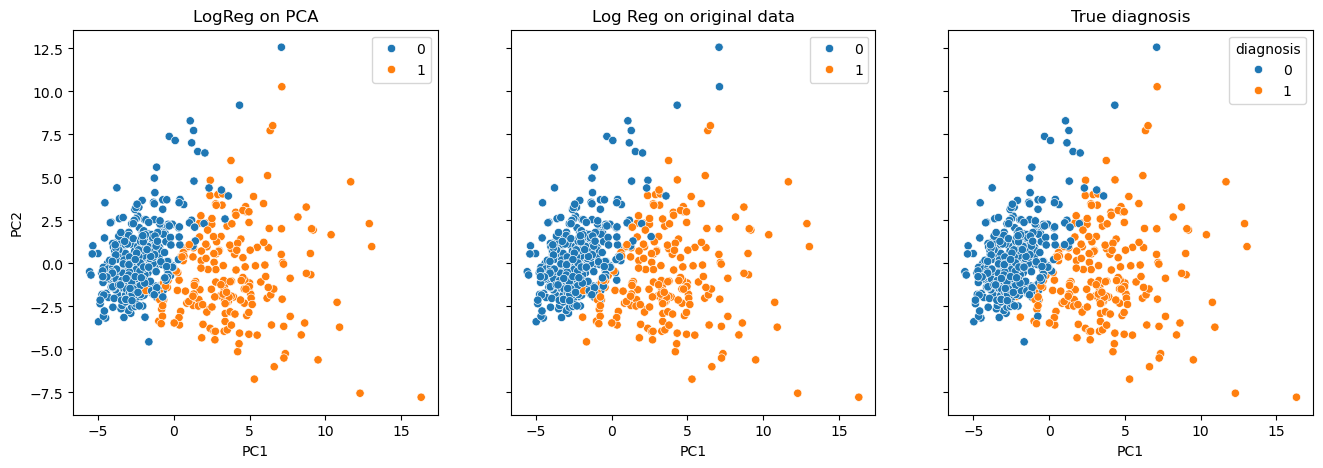

In [34]:
# this line allows us to make 3 plots next to each other
# and adjusts figure size to work for 3 plots
# look up the matplotlib library for subplots to learn more
f, axes = plt.subplots(1, 3, sharey=True, figsize = (16,5))

# create chart in first subplot axes[0]
sns.scatterplot(x=X_5PCs.PC1, y=X_5PCs.PC2, hue = y_pred_all, ax=axes[0])
axes[0].set_title('LogReg on PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# create chart in second subplot axes[1]
sns.scatterplot(x=X_5PCs.PC1, y=X_5PCs.PC2, hue = y_pred_all2, ax=axes[1])
axes[1].set_title('Log Reg on original data')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# create chart in third subplot axes[2]
sns.scatterplot(x=X_5PCs.PC1, y=X_5PCs.PC2, hue = data['diagnosis'], ax=axes[2])
axes[2].set_title('True diagnosis')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')


Since accuracy is quite high for both classifiers, both predictors are very close to the true diagnoses. We know however that we main some accuracy gains, and we can keep in mind next time we do classification and achieve low accuracy that PCA or dimension reduction, more generally, can help us improve predictions. 

This notebook has been adapted from https://www.kaggle.com/code/jyotiprasadpal/dimension-reduction-methods/notebook.